# Researcher Notebook — Tip 1: Cross-Sectional Normalization

Key insight: many strategies share each `TS`, so a large chunk of "noise" is actually a common per-date market factor. Stripping it out leaves strategy-specific residual signal.

**Features added beyond benchmark:**
1. Within-date z-score of every `RET_k` and `SIGNED_VOLUME_k`
2. Cross-sectional rank of momentum at horizons 1, 3, 5, 10, 20 and of signed-volume
3. Date-level aggregates: return dispersion (std across strategies), percentile rank of strategy return vs cross-section

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

import lightgbm as lgbm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

### Load data

In [8]:
X_train = pd.read_csv('../../data/X_train.csv', index_col='ROW_ID')
X_test  = pd.read_csv('../../data/X_test.csv', index_col='ROW_ID')
y_train = pd.read_csv('../../data/y_train.csv', index_col='ROW_ID')
sample_submission = pd.read_csv('../../submission/sample_submission.csv', index_col='ROW_ID')

RET_cols  = [f'RET_{i}'           for i in range(1, 21)]
VOL_cols  = [f'SIGNED_VOLUME_{i}' for i in range(1, 21)]

### Feature engineering

#### A. Benchmark features (rolling means + cross-allocation means + vol)

In [9]:
def add_benchmark_features(df):
    for i in [3, 5, 10, 15, 20]:
        df[f'AVERAGE_PERF_{i}'] = df[RET_cols[:i]].mean(axis=1)
        df[f'ALLOCATIONS_AVERAGE_PERF_{i}'] = df.groupby('TS')[f'AVERAGE_PERF_{i}'].transform('mean')
    df['STD_PERF_20'] = df[RET_cols].std(axis=1)
    df['ALLOCATIONS_STD_PERF_20'] = df.groupby('TS')['STD_PERF_20'].transform('mean')
    return df

X_train = add_benchmark_features(X_train)
X_test  = add_benchmark_features(X_test)

#### B. Tip 1 — Within-date z-score of raw return and volume features

For every lag k, replace `RET_k` with its within-date z-score so the common daily market factor is stripped out. Same for `SIGNED_VOLUME_k`.

In [10]:
def add_xs_zscore_features(df):
    for col in RET_cols + VOL_cols:
        grp = df.groupby('TS')[col]
        mean_ = grp.transform('mean')
        std_  = grp.transform('std').replace(0, np.nan)
        df[f'XS_Z_{col}'] = (df[col] - mean_) / std_
    return df

X_train = add_xs_zscore_features(X_train)
X_test  = add_xs_zscore_features(X_test)

xs_z_features = [f'XS_Z_{c}' for c in RET_cols + VOL_cols]
print(f"Added {len(xs_z_features)} within-date z-score features")

Added 40 within-date z-score features


#### C. Tip 1 — Cross-sectional ranks of momentum at multiple horizons

Scale-free, regime-robust. Rank each strategy's rolling-mean return and signed-volume against peers on the same date.

In [11]:
def add_xs_rank_features(df):
    rank_features = []
    # horizon->source column map (AVERAGE_PERF_1 doesn't exist; use RET_1 directly)
    horizon_col = {1: 'RET_1', 3: 'AVERAGE_PERF_3', 5: 'AVERAGE_PERF_5',
                   10: 'AVERAGE_PERF_10', 20: 'AVERAGE_PERF_20'}
    for i, col in horizon_col.items():
        new_col = f'XS_RANK_RET_{i}'
        df[new_col] = df.groupby('TS')[col].rank(pct=True)
        rank_features.append(new_col)
    # Rank rolling-mean signed volume (horizon 1 and 5)
    for i in [1, 5]:
        col = f'SVOL_MEAN_{i}'
        df[col] = df[VOL_cols[:i]].mean(axis=1)
        new_col = f'XS_RANK_SVOL_{i}'
        df[new_col] = df.groupby('TS')[col].rank(pct=True)
        rank_features.append(new_col)
    return df, rank_features

X_train, rank_features = add_xs_rank_features(X_train)
X_test,  _             = add_xs_rank_features(X_test)
print(f"Added {len(rank_features)} cross-sectional rank features:", rank_features)

Added 7 cross-sectional rank features: ['XS_RANK_RET_1', 'XS_RANK_RET_3', 'XS_RANK_RET_5', 'XS_RANK_RET_10', 'XS_RANK_RET_20', 'XS_RANK_SVOL_1', 'XS_RANK_SVOL_5']


/var/folders/9_/_hcc1_5d3mbf6gs_r1f4gbsm0000gn/T/ipykernel_62398/1357927859.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col] = df.groupby('TS')[col].rank(pct=True)
/var/folders/9_/_hcc1_5d3mbf6gs_r1f4gbsm0000gn/T/ipykernel_62398/1357927859.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = df[VOL_cols[:i]].mean(axis=1)
/var/folders/9_/_hcc1_5d3mbf6gs_r1f4gbsm0000gn/T/ipykernel_62398/1357927859.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inse

#### D. Tip 1 — Date-level aggregate context features

These tell the model *how unusual this strategy is relative to today's cross-section*: the date's mean return, cross-sectional dispersion, and each strategy's percentile in RET_1.

In [12]:
def add_date_context_features(df):
    agg_features = []
    # Cross-sectional dispersion of RET_1 (how spread-out strategies are today)
    df['XS_DISP_RET1'] = df.groupby('TS')['RET_1'].transform('std')
    agg_features.append('XS_DISP_RET1')

    # Cross-sectional dispersion of RET_5 mean
    df['XS_DISP_RET5'] = df.groupby('TS')['AVERAGE_PERF_5'].transform('std')
    agg_features.append('XS_DISP_RET5')

    # Date-level mean of RET_1 (common market factor on most recent day)
    df['XS_MEAN_RET1'] = df.groupby('TS')['RET_1'].transform('mean')
    agg_features.append('XS_MEAN_RET1')

    # Percentile of this strategy's RET_1 within the cross-section (same as XS_RANK_RET_1 but kept separate for clarity)
    df['XS_PCT_RET1'] = df.groupby('TS')['RET_1'].rank(pct=True)
    agg_features.append('XS_PCT_RET1')

    # Cross-sectional dispersion of signed volume
    df['XS_DISP_SVOL1'] = df.groupby('TS')['SIGNED_VOLUME_1'].transform('std')
    agg_features.append('XS_DISP_SVOL1')

    return df, agg_features

X_train, agg_features = add_date_context_features(X_train)
X_test,  _            = add_date_context_features(X_test)
print(f"Added {len(agg_features)} date-context features:", agg_features)

Added 5 date-context features: ['XS_DISP_RET1', 'XS_DISP_RET5', 'XS_MEAN_RET1', 'XS_PCT_RET1', 'XS_DISP_SVOL1']


/var/folders/9_/_hcc1_5d3mbf6gs_r1f4gbsm0000gn/T/ipykernel_62398/1504604610.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['XS_DISP_RET1'] = df.groupby('TS')['RET_1'].transform('std')
/var/folders/9_/_hcc1_5d3mbf6gs_r1f4gbsm0000gn/T/ipykernel_62398/1504604610.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['XS_DISP_RET5'] = df.groupby('TS')['AVERAGE_PERF_5'].transform('std')
/var/folders/9_/_hcc1_5d3mbf6gs_r1f4gbsm0000gn/T/ipykernel_62398/1504604610.py:12: PerformanceWarning: DataFrame is highly fragmented.  This 

### Build final feature list

In [13]:
benchmark_features = (
    RET_cols + VOL_cols + ['MEDIAN_DAILY_TURNOVER']
    + [f'AVERAGE_PERF_{i}'            for i in [3, 5, 10, 15, 20]]
    + [f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3, 5, 10, 15, 20]]
    + ['STD_PERF_20', 'ALLOCATIONS_STD_PERF_20']
)

features = benchmark_features + xs_z_features + rank_features + agg_features
print(f"Total features: {len(features)}  "
      f"(benchmark={len(benchmark_features)}, xs_z={len(xs_z_features)}, "
      f"ranks={len(rank_features)}, agg={len(agg_features)})")

Total features: 105  (benchmark=53, xs_z=40, ranks=7, agg=5)


### LightGBM — 8-fold cross-validation on dates

In [14]:

lgbm_params = {
    "objective":     "mse",
    "metric":        "mse",
    "num_threads":   50,
    "seed":          42,
    "verbosity":     -1,
    "learning_rate": 1e-2,
    "max_depth":     3,
}
NUM_BOOST_ROUND = 500

train_dates = X_train['TS'].unique()
n_splits    = 8
scores      = []
models      = []

splits = KFold(n_splits=n_splits, shuffle=True, random_state=0).split(train_dates)

for fold, (tr_idx, val_idx) in enumerate(splits):
    tr_dates  = train_dates[tr_idx]
    val_dates = train_dates[val_idx]

    tr_mask  = X_train['TS'].isin(tr_dates)
    val_mask = X_train['TS'].isin(val_dates)

    X_tr  = X_train.loc[tr_mask,  features].fillna(0)
    y_tr  = y_train.loc[tr_mask,  'target']
    X_val = X_train.loc[val_mask, features].fillna(0)
    y_val = y_train.loc[val_mask, 'target']

    train_data = lgbm.Dataset(X_tr, label=y_tr.values)
    model      = lgbm.train(lgbm_params, train_data, num_boost_round=NUM_BOOST_ROUND)

    preds = model.predict(X_val.values, num_threads=lgbm_params['num_threads'])
    acc   = accuracy_score((y_val > 0).astype(int), (preds > 0).astype(int))

    models.append(model)
    scores.append(acc)
    print(f"Fold {fold+1} — Accuracy: {acc*100:.2f}%")

mean = np.mean(scores) * 100
std  = np.std(scores)  * 100
print(f"\nAccuracy: {mean:.2f}% ± {std:.2f}%  [{mean-std:.2f} ; {mean+std:.2f}]")

Fold 1 — Accuracy: 51.96%
Fold 2 — Accuracy: 52.25%
Fold 3 — Accuracy: 52.02%
Fold 4 — Accuracy: 52.18%
Fold 5 — Accuracy: 51.86%
Fold 6 — Accuracy: 52.24%
Fold 7 — Accuracy: 52.28%
Fold 8 — Accuracy: 52.00%

Accuracy: 52.10% ± 0.15%  [51.95 ; 52.25]


### Feature importance (top 30 by gain)

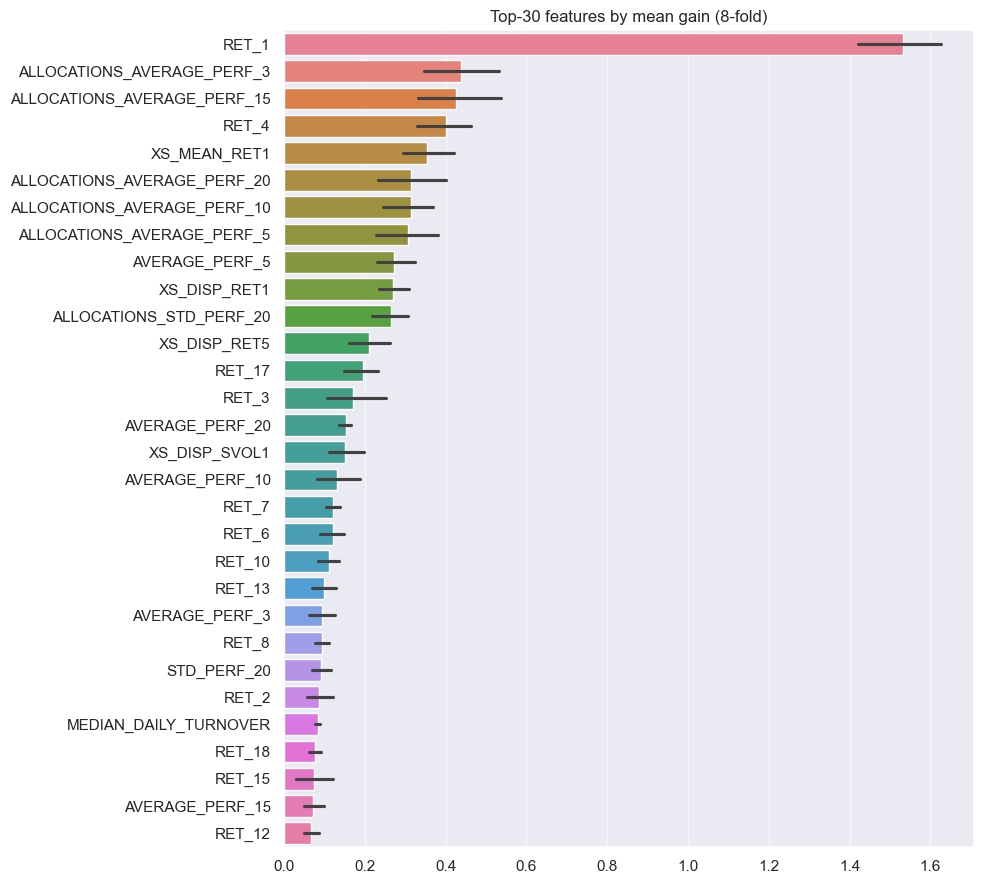

In [15]:
importances = pd.DataFrame(
    [m.feature_importance(importance_type='gain') for m in models],
    columns=features
)
top30 = importances.mean().sort_values(ascending=False).head(30).index

plt.figure(figsize=(10, 9))
sns.barplot(
    data=importances[top30],
    orient='h',
    order=importances[top30].mean().sort_values(ascending=False).index
)
plt.title("Top-30 features by mean gain (8-fold)")
plt.tight_layout()
plt.show()

### Final model — train on all data and write submission

In [16]:
full_train_data = lgbm.Dataset(X_train[features].fillna(0), label=y_train['target'].values)
final_model     = lgbm.train(lgbm_params, full_train_data, num_boost_round=NUM_BOOST_ROUND)

test_preds = final_model.predict(X_test[features].fillna(0).values)
submission = pd.DataFrame(
    (test_preds > 0).astype(int),
    index=sample_submission.index,
    columns=['TARGET']
)
submission.to_csv('xs_norm.csv')
print("Saved xs_norm.csv")
submission['TARGET'].value_counts()

Saved preds_tip1_xs_norm.csv


TARGET
1    18522
0    13348
Name: count, dtype: int64